## Import Libraries and Dataset

In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [83]:
df = pd.read_csv('Housing.csv')
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


## Exploratory Data Analysis (EDA)

In [84]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [85]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [86]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
540    False
541    False
542    False
543    False
544    False
Length: 545, dtype: bool

array([[<Axes: title={'center': 'area'}>,
        <Axes: title={'center': 'bedrooms'}>,
        <Axes: title={'center': 'bathrooms'}>,
        <Axes: title={'center': 'price'}>]], dtype=object)

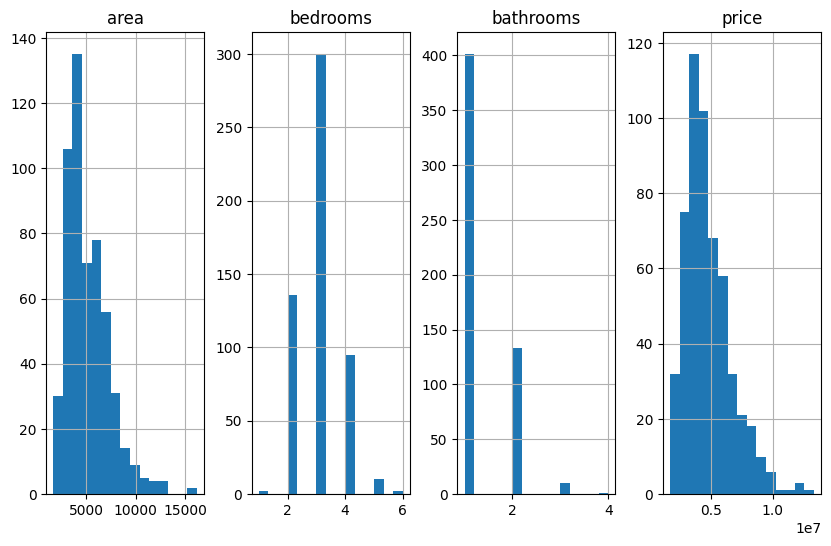

In [87]:
df[['area', 'bedrooms', 'bathrooms', 'price']].hist(bins=15,figsize=(10,6),layout=(1,4))

<Axes: >

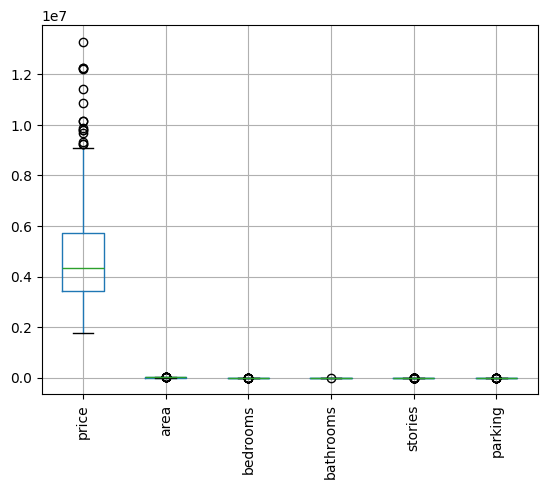

In [88]:
df.boxplot(rot=90)

## Data Cleaning


In [89]:
out = ['price', 'area']
df_filtered = df.copy()
for i in out:
    q1 = np.percentile(df[i], 25)
    q3 = np.percentile(df[i], 75)
    iqr = q3 - q1
    upper = q3 + 1.5*iqr
    lower = q1 - 1.5*iqr
    filtered = (df[i]>=lower) & (df[i]<=upper)
    df_filtered = df.loc[filtered]

(545, 13)

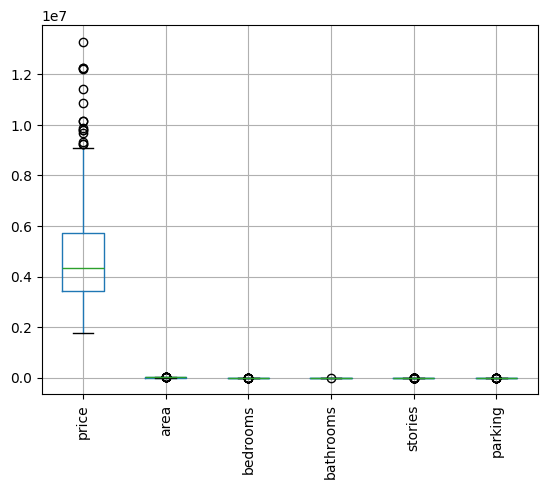

In [90]:
df.boxplot(rot=90)

df.shape

(533, 13)

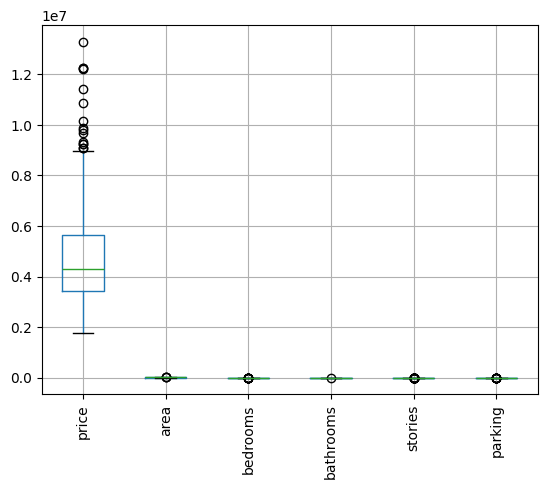

In [91]:
df_filtered.boxplot(rot=90)
df_filtered.shape

## Scaling DataFrame

In [92]:
categorical_yes_no = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']
# df[categorical_yes_no] = df[categorical_yes_no].apply(lambda x: x.map({'yes':1, 'no':0}))
df_encoded = pd.get_dummies(df, columns=categorical_yes_no, drop_first=True, dtype='uint8' )

In [93]:
# Define features and target
X = df_encoded.drop('price', axis=1)
y = df_encoded['price']

In [94]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [95]:
X_train

,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
46,6000,3,2,4,1,1,0,0,0,1,0,0,0
93,7200,3,2,1,3,1,0,1,0,1,0,1,0
335,3816,2,1,1,2,1,0,1,0,1,0,0,0
412,2610,3,1,2,0,1,0,1,0,0,1,0,1
471,3750,3,1,2,0,1,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,6000,4,2,4,0,1,0,0,0,1,0,0,1
106,5450,4,2,1,0,1,0,1,0,1,1,1,0
270,4500,3,2,3,1,1,0,0,1,0,0,0,0
435,4040,2,1,1,0,1,0,0,0,0,0,0,1


In [96]:
numeric_features = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']


categorical_features = [col for col in X_train.columns if col not in numeric_features]
categorical_features

['mainroad_yes',
 'guestroom_yes',
 'basement_yes',
 'hotwaterheating_yes',
 'airconditioning_yes',
 'prefarea_yes',
 'furnishingstatus_semi-furnished',
 'furnishingstatus_unfurnished']

In [97]:
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
preprocessor = ColumnTransformer(
    transformers = [
        ('num', StandardScaler(), numeric_features),
        ('cat', 'passthrough', categorical_features)
    ]
)
X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

In [98]:
X_test_scaled = pd.DataFrame(X_test_scaled, columns=[numeric_features+categorical_features])

In [99]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=[numeric_features+categorical_features])

In [100]:
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

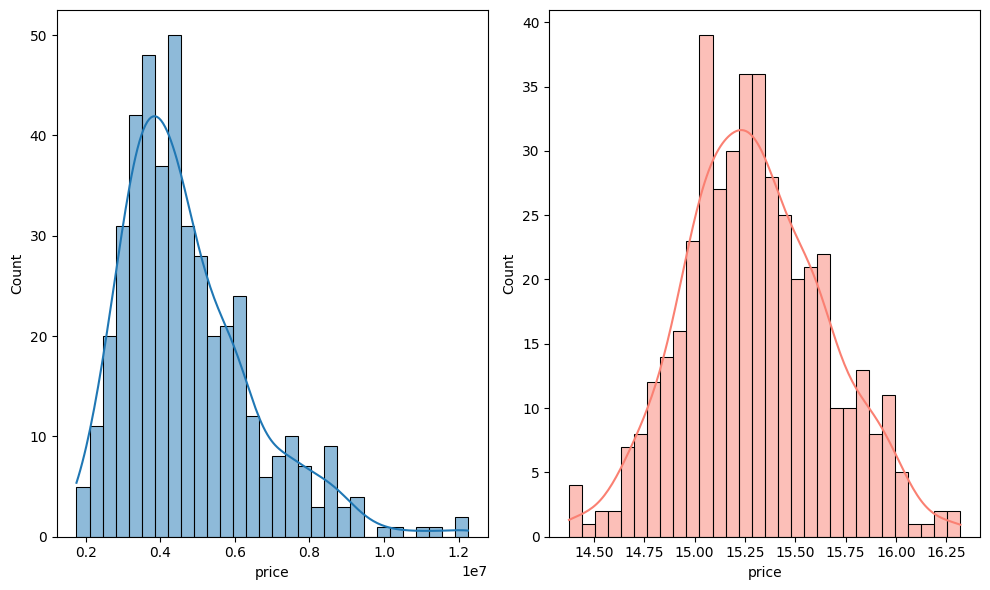

In [101]:
plt.figure(figsize=(10,6))

plt.subplot(1,2,1)
sns.histplot(y_train, kde=True, bins=30)

plt.subplot(1,2,2)
sns.histplot(y_train_log, kde=True, bins=30, color= 'salmon')

plt.tight_layout()

## Linear Regression Model

In [102]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train_log)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [103]:
from sklearn.metrics import mean_squared_error, r2_score
lin_pred = lin_reg.predict(X_test_scaled)
mse_lin = mean_squared_error(y_test_log, lin_pred)
mse_lin

0.06329354097113263

In [104]:
r2_lin = r2_score(y_test_log, lin_pred)
r2_lin

0.6722047416501389

## Polynomial Regression

In [105]:
from sklearn.preprocessing import PolynomialFeatures
poly_features = PolynomialFeatures(degree=2)
X_train_poly = poly_features.fit_transform(X_train)
X_test_poly = poly_features.transform(X_test)

In [106]:
lin_poly_reg = LinearRegression()
lin_poly_reg.fit(X_train_poly, y_train_log)
poly_pred = lin_poly_reg.predict(X_test_poly)

In [107]:
mse_poly = mean_squared_error(y_test_log, poly_pred)
mse_poly

0.0747790426477352

In [108]:
r2_poly = r2_score(y_test_log, poly_pred)
r2_poly

0.612721689642086

## SVR Model

In [109]:
from sklearn.svm import SVR
svr_lin = SVR()
svr_lin.fit(X_train_scaled, y_train_log)
svr_pred = svr_lin.predict(X_test_scaled)

In [110]:
mse_svr = mean_squared_error(y_test_log, svr_pred)
r2_svr = r2_score(y_test_log, svr_pred)
print(mse_svr)
print(r2_svr)

0.07401927900723854
0.6166564816445594


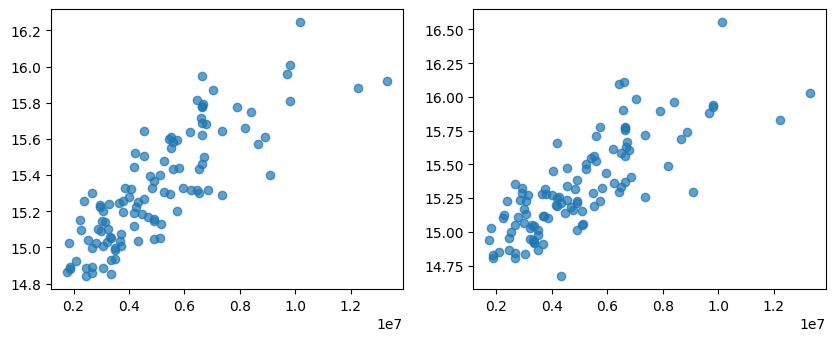

In [111]:
plt.figure(figsize= (10,8))

plt.subplot(2,2,1)
plt.scatter(y_test, lin_pred,alpha=0.7)

plt.subplot(2,2,2)
plt.scatter(y_test, poly_pred, alpha=0.7)



## KNN Model

In [112]:
from sklearn.neighbors import KNeighborsRegressor
knn_reg = KNeighborsRegressor(n_neighbors = 5)
knn_reg.fit(X_train_scaled, y_train_log)
knn_pred = knn_reg.predict(X_test_scaled)

In [113]:
y_train_log

46     15.833742
93     15.656060
335    15.181602
412    15.048071
471    14.917451
         ...    
71     15.725794
106    15.633587
270    15.283385
435    15.006398
102    15.639253
Name: price, Length: 436, dtype: float64

In [114]:
mse_knn = mean_squared_error(y_test_log, knn_pred)
r2_knn = r2_score(y_test_log, knn_pred)
print(mse_knn)
print(r2_knn)

0.07618193013875471
0.6054561794415386


## Lasso Regression Model

In [115]:
from sklearn.linear_model import Lasso
lass_reg = Lasso(alpha=0.001)
lass_reg.fit(X_train_scaled, y_train_log)
lass_pred = lass_reg.predict(X_test_scaled)

In [116]:
from sklearn.metrics import root_mean_squared_error
lass_mse = mean_squared_error(y_test_log, lass_pred)
lass_r2 = r2_score(y_test_log, lass_pred)
lass_rmse = root_mean_squared_error(y_test_log, lass_pred)
print(lass_mse)
print(lass_r2)
print(lass_rmse)

0.06413566523088077
0.6678434065904884
0.25325020282495486


## Ridge Regression Model

In [117]:
from sklearn.linear_model import Ridge
rid = Ridge(alpha= 0.001)
rid.fit(X_train_scaled, y_train_log)
rid_pred = rid.predict(X_test_scaled)

In [118]:
rid_mse = mean_squared_error(y_test_log, rid_pred)
rid_rmse = root_mean_squared_error(y_test_log, rid_pred)
rid_r2 = r2_score(y_test_log, rid_pred)
print(rid_mse)
print(rid_rmse)
print(rid_r2)

0.06329370822700717
0.2515824084211914
0.6722038754372242


## Cross Validation on Linear Regression

In [119]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
y_log = np.log1p(y)


In [ ]:
from sklearn.model_selection import cross_val_score
model = LinearRegression()

scores = cross_val_score(model, X_scaled, y_log, cv=5, scoring= 'neg_mean_squared_error')  # because it's common to consider MSE as a loss function (lower is better)

mse_scores = -scores # Convert scores to positive MSE

print(f'The accuracies{mse_scores}')

# Calculate the mean and standard deviation of the MSE scores
mse_mean = np.mean(mse_scores)
mse_std = np.std(mse_scores)

print(f'Mean Squared Error from 5-fold CV:{mse_mean}')
print(f'Standard Deviation from 5-fold CV: {mse_std}')

The accuracies[0.12791625 0.03541888 0.03383629 0.0344389  0.12294919]
Mean Squared Error from 5-fold CV:0.07091190237894983
Standard Deviation from 5-fold CV: 0.04454662781588148


## Cross Validation on Ridge Regression

In [121]:
ridge_reg = Ridge(alpha= 0.01)
scores_rid = cross_val_score(ridge_reg, X_scaled,y_log, cv=5, scoring= 'neg_mean_squared_error')
mse_scores_rid = -scores_rid
mean_mse_rid = np.mean(mse_scores_rid)
std_mse_rid= np.std(mse_scores_rid)
print(f'Mean Squared Error from 5-fold CV: {mean_mse_rid}')
print(f'Standard Deviation Squared Error from 5-fold CV: {mean_mse_rid}')

Mean Squared Error from 5-fold CV: 0.07091279759123167
Standard Deviation Squared Error from 5-fold CV: 0.07091279759123167


## Grid Search

In [122]:
from sklearn.model_selection import GridSearchCV, cross_val_score, KFold
from sklearn.ensemble import RandomForestRegressor

In [123]:
param_grid = {
    'n_estimators' : [50,100,200],
    'max_features' : [1,5,10],
    'max_depth' : [None, 10,20,30],
    'min_samples_split' : [2,10,20],
    'min_samples_leaf' : [1,2,4]
}

rf = RandomForestRegressor(random_state=42)
grid_search_rf = GridSearchCV(estimator= rf,param_grid= param_grid, cv = 5, scoring='neg_mean_squared_error')
grid_search_rf.fit(X_scaled,y_log)
best_params = grid_search_rf.best_params_
best_score = -grid_search_rf.best_score_
print("Best parameters:", best_params)
print("Best cross-validation MSE:", best_score)

Best parameters: {'max_depth': None, 'max_features': 5, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 200}
Best cross-validation MSE: 0.09728266152758779


In [125]:
param_grid = {
    'n_estimators' : [50,100,200],
    'max_features' : [1,5,10],
    'max_depth' : [None, 10,20,30],
    'min_samples_split': [2,10,20],
    'min_samples_leaf' : [1,2,4]
}

rf = RandomForestRegressor(random_state=42)
gcvr = GridSearchCV(estimator = rf, param_grid= param_grid, cv=5, scoring='neg_mean_squared_error')
gcvr.fit(X_scaled,y_log)

best_params = gcvr.best_params_
best_score = -gcvr.best_score_

In [ ]:
rf_best = RandomForestRegressor(**best_params, random_state= 42)
rf_best.fit(X_train_scaled, y_train_log)
rf_best_pred = rf_best.predict(X_test_scaled)
rf_best_mse = mean_squared_error(y_test_log, rf_best_pred)
rf_best_r2 = r2_score(y_test_log, rf_best_pred)
print(rf_best_mse)
print(rf_best_r2)

0.07264979461159074
0.6237489982645761


In [ ]:
knn_regres = KNeighborsRegressor()
param_grid= {'n_neighbors' : np.arange(1,30)}
gscv = GridSearchCV(knn_regres, param_grid, cv=5)
gscv.fit(X_scaled,y_log)


In [135]:
gscv_best_params = gscv.best_params_['n_neighbors']
knn_reg = KNeighborsRegressor(n_neighbors= gscv_best_params)
knn_reg.fit(X_train_scaled, y_train_log)
knn_reg_pred = knn_reg.predict(X_test_scaled)
mse_best = mean_squared_error(y_test_log, knn_reg_pred)
mse_best

0.08480712408316342

# Ensemble learning

## Bagging

In [ ]:
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor

base = DecisionTreeRegressor(max_depth = 3,random_state =42)

# Create a Bagging ensemble of 100 Decision Trees
bagging_model = BaggingRegressor(estimator = base, n_estimators=100, random_state=42)
bagging_model.fit(X_train_scaled, y_train_log)
bagging_model_pred = bagging_model.predict(X_test_scaled)
bagging_model_mse = mean_squared_error(y_test_log, bagging_model_pred)
bagging_model_r2_score = r2_score(y_test_log, bagging_model_pred)
print(bagging_model_mse)
print(bagging_model_r2_score)

0.08855993250797242
0.5413508944121631


## AdaBoost

In [ ]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import AdaBoostClassifier

ada_boost = AdaBoostRegressor(n_estimators = 50, random_state = 42)
ada_boost.fit(X_train_scaled, y_train_log)
ada_boost_pred = ada_boost.predict(X_test_scaled)
ada_mse = mean_squared_error(y_test_log, ada_boost_pred)
print(ada_mse)

0.08007364783747639


## Gradient Boosting

In [155]:
from sklearn.ensemble import GradientBoostingRegressor

gradient = GradientBoostingRegressor(n_estimators = 50, learning_rate = 0.1, max_depth = 3, random_state = 42)

gradient.fit(X_train_scaled, y_train_log)
gradient_pred =  gradient.predict(X_test_scaled)
gradient_mse = mean_squared_error(y_test_log, gradient_pred)
gradient_rmse = root_mean_squared_error(y_test_log, gradient_pred)
gradient_r2 = r2_score(y_test_log, gradient_pred)
print(gradient_mse)
print(gradient_rmse)
print(gradient_r2)

0.06502132190638239
0.2549927879497426
0.6632566185185784


## XGBOOST

In [161]:
import xgboost as xgb

xg_reg = xgb.XGBRegressor(objective = 'reg:squarederror', colsample_bytree= 0.3, learning_rate = 0.1, max_depth=5, alpha = 10, n_estimators =10)

xg_reg.fit(X_train_scaled, y_train_log)
xg_pred = xg_reg.predict(X_test_scaled)

xg_rmse = root_mean_squared_error(y_test_log, xg_pred)
xg_rmse

0.3840548465624388

## Combining Models with Stacking

In [168]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import LinearRegression

estimators = [
    ('forest', RandomForestRegressor(n_estimators = 100, random_state= 42)),
    ('grad_reg', GradientBoostingRegressor(n_estimators =50, learning_rate = 0.1, max_depth=3, random_state = 42))
]

stack_boost = StackingRegressor(estimators = estimators, final_estimator = LinearRegression(), cv = 5)

stack_boost.fit(X_train_scaled, y_train_log)
stack_pred = stack_boost.predict(X_test_scaled)
stack_mse = mean_squared_error(y_test_log, stack_pred)
stack_r2 = r2_score(y_test_log, stack_pred)
print(stack_mse)
print(stack_r2)

0.0652596560529637
0.6620222934681306
